In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import copy
import numpy as np
import xarray as xr
import glob 

from causaldynamics.scm import create_scm_graph
from causaldynamics.plot import plot_scm
from causaldynamics.score import score
# from causaldynamics.baselines import PCMCIPlus
# from causaldynamics.baselines import FPCMCI
# from causaldynamics.baselines import DYNOTEARS
# from causaldynamics.baselines import VARLiNGAM
# from causaldynamics.baselines import NGC_LSTM
# from causaldynamics.baselines import TSCI
# from causaldynamics.baselines import CUTSPlus
# # from causaldynamics.baselines import RCD
# # from causaldynamics.baselines import GIN
# # from causaldynamics.baselines import GRASP
# from causaldynamics.baselines import TCDF

# DYNOTEARS / FPCMCI + not sure about PCMCIPlus + VARLiNGAM

from tqdm import tqdm
from pathlib import Path
import torch

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt 

from causaldynamics.baselines import PICABU, StructuredLowRankDiscovery, StructuredODEDiscovery, StructuredODEDiscoveryAGL

In [3]:
DATA_DIR = Path("../data/climate/coupled_atmos_ocean/data")  # (you can change this to your own path)
ds = xr.open_dataset(DATA_DIR / "ESM_N10_T1000.nc")

# NOTE: If dataset is from coupled system e.g., "../data/coupled/...", follow these changes to load the data:
timeseries = ds['time_series'].to_numpy()[..., 0].transpose(1, 0, 2) ## select the first dimension of each multidimensional node
adj_matrix = ds['adjacency_matrix'].to_numpy() ## `adjacency_matrix_summary` is the true adjacency matrix for coupled system

n_systems = adj_matrix.shape[0]

In [4]:
timeseries.shape

(10, 1000, 4)

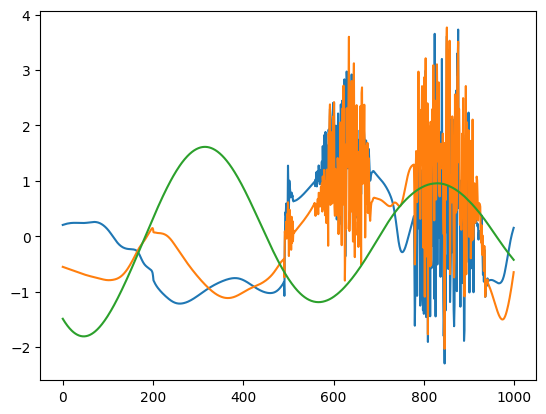

In [5]:
for k in range(1):
    
    timeseries_norm = timeseries[k]
    timeseries_norm -= timeseries_norm.mean(0)
    timeseries_norm /= timeseries_norm.std(0)
    
    plt.figure()
    for j in range(4):
        plt.plot(timeseries_norm[:, j])
    plt.show()
    plt.close()


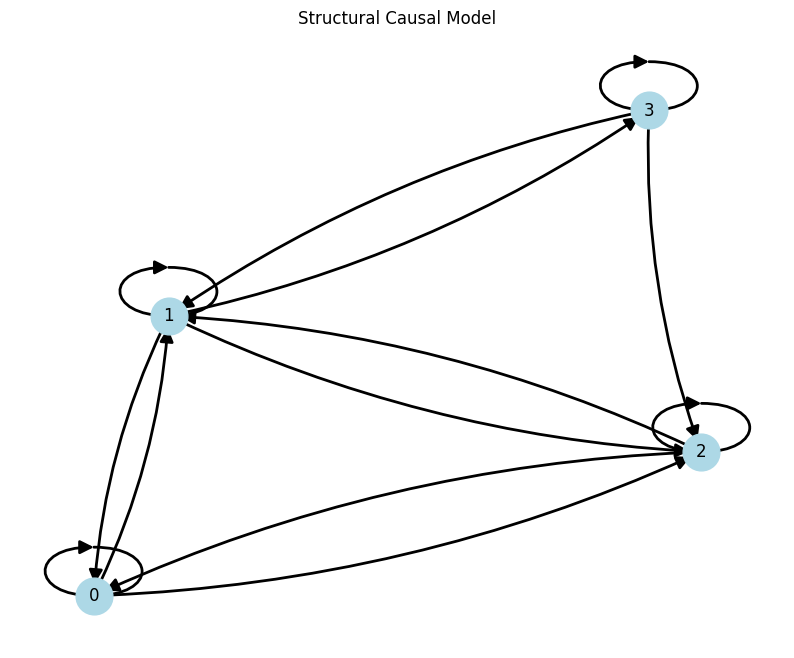

In [6]:
G = create_scm_graph(adj_matrix)
plot_scm(G);


In [7]:
timeseries_stacked = timeseries[:, :, None]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [8]:
glob.glob("../data/climate/coupled_atmos_ocean/data/*.nc")

['../data/climate/coupled_atmos_ocean/data/ESM_N10_T1000.nc']

In [9]:
ds = xr.open_dataset(DATA_DIR / "ESM_N10_T1000.nc")

# NOTE: If dataset is from coupled system e.g., "../data/coupled/...", follow these changes to load the data:
timeseries = ds['time_series'].to_numpy()[..., 0].transpose(1, 0, 2) ## select the first dimension of each multidimensional node
adj_matrix = ds['adjacency_matrix'].to_numpy() ## `adjacency_matrix_summary` is the true adjacency matrix for coupled system

n_systems = adj_matrix.shape[0]

In [10]:
adj_matrix

array([[1., 1., 1., 0.],
       [1., 1., 1., 1.],
       [1., 1., 1., 0.],
       [0., 1., 1., 1.]], dtype=float32)

In [ ]:
tau_max = 1 # i.e. no delay 

## Estimate adjacency matrix
lowrank_adj_matrix = []

all_shd = []
all_auroc = []
all_auprc = []

lambda_m_hp = 0.03

for x in timeseries[:, :, None]:

    # lowrank_model = StructuredODEDiscoveryAGL(
    #     coupled=False,
    #     t = tau_max,
    #     n = N,
    #     hidden_dim = 8, 
    #     n_layers = 2,
    #     device = device,
    #     normalize_grad = True,
    # )
    # trained_model, mask = lowrank_model.run(lambda_grad=0, X=torch.tensor(x).to(device), lambda_init = 0., lambda_m = 0.05, lr=0.001, n_inner_min_sparse = 50, batch_size=128, n_inner=1_000, patience = 1000, save_fig_path="agl_loss.png")
    lowrank_model = StructuredODEDiscovery(
        coupled=False,
        t = tau_max,
        n = n_systems,
        L_lipschitz = 1, 
        is_lipschitz = False,
        hidden_dim = 8, 
        n_layers = 2,
        device = device,
        beta_init = 0.33, 
        beta_min = 0.33,
        annealing_rate = 0.95,
        annealing_epochs = 10,
        normalize_grad = True,
    )
    trained_model, mask = lowrank_model.run(n_samples=3, lambda_grad=100, X=torch.tensor(x).to(device), l0_l1_l2='l1', th=0.5, lr=0.001, lambda_m = 50., n_inner_min_sparse = 100, batch_size=128, n_inner=2_000, patience = 200, save_fig_path="couple_005_loss.png")
    lowrank_adj_matrix.append(mask.detach().cpu().numpy())
#     lowrank_S_matrix.append(copy.deepcopy(lowrank_model.model.S))
    
    mask_numpy = mask.detach().cpu().numpy()

    results_scores = score(
        preds= mask_numpy, #.transpose((0, 2, 1)), # Need to transpos
        labs= adj_matrix,
        name='LR_discovery',
        shd_threshold = 1e-8,
    )

    print(results_scores)

    all_shd.append(results_scores.loc["Joint SHD", "LR_discovery"])
    all_auroc.append(results_scores.loc["Joint AUROC", "LR_discovery"])
    all_auprc.append(results_scores.loc["Joint AUPRC", "LR_discovery"])


Dimensions: N=4, T=1
Number of NaN values in X: False
Number of NaN values after normalization in X: False
Constant dimensions in X: (tensor([3], device='cuda:0'),)
X_t_all.shape: torch.Size([999, 1, 4])
X_last_all.shape: torch.Size([999, 1, 4])
recon=0.3652  |M|_1=0.005  grad_penalty=0.0003  
Scoring...
                  LR_discovery
Metric                        
Joint AUROC           0.910256
Individual AUROC      0.910256
Null AUROC            0.500000
Joint AUPRC           0.971992
Individual AUPRC      0.971992
Null AUPRC            0.812500
Joint SHD             4.000000
Dimensions: N=4, T=1
Number of NaN values in X: False
Number of NaN values after normalization in X: False
Constant dimensions in X: (tensor([3], device='cuda:0'),)
X_t_all.shape: torch.Size([999, 1, 4])
X_last_all.shape: torch.Size([999, 1, 4])
recon=0.3729  |M|_1=0.005  grad_penalty=0.0003  
Scoring...
                  LR_discovery
Metric                        
Joint AUROC           0.961538
Individual AUROC

In [14]:
results_scores = score(
    preds= np.array(lowrank_adj_matrix)[:, 0], #.transpose((0, 2, 1)), # Need to transpos
    labs= adj_matrix,
    name='LR_discovery',
    shd_threshold = 1e-8,
)
results_scores

Scoring...


,LR_discovery
Metric,
Joint AUROC,0.876282
Individual AUROC,0.908974
Null AUROC,0.500000
Joint AUPRC,0.969224
Individual AUPRC,0.971725
Null AUPRC,0.812500
Joint SHD,42.000000


In [16]:
adj_matrix

array([[1., 1., 1., 0.],
       [1., 1., 1., 1.],
       [1., 1., 1., 0.],
       [0., 1., 1., 1.]], dtype=float32)

In [15]:
lowrank_adj_matrix

[array([[[5.7635270e-04, 7.0528762e-04, 8.7787927e-04, 2.7359569e-11],
         [4.9844536e-04, 5.7277095e-04, 8.6810836e-04, 2.7377683e-11],
         [3.9442483e-04, 3.2869613e-04, 6.4055866e-04, 2.7380449e-11],
         [2.7405059e-11, 2.7405059e-11, 2.7405059e-11, 2.7405059e-11]]],
       dtype=float32),
 array([[[5.7383318e-04, 1.2383188e-04, 6.4036669e-04, 2.7399468e-11],
         [3.3728313e-05, 3.4140679e-04, 7.9418375e-04, 2.7405687e-11],
         [5.6900119e-04, 6.2373216e-04, 9.0793415e-04, 2.7403803e-11],
         [2.7405059e-11, 2.7405059e-11, 2.7405059e-11, 2.7405059e-11]]],
       dtype=float32),
 array([[[8.4255321e-04, 1.8142709e-04, 1.4704342e-10, 5.0218878e-11],
         [4.4510898e-04, 3.7502649e-04, 5.0646142e-04, 5.0207290e-11],
         [1.1989967e-03, 7.1466010e-04, 7.9454528e-04, 5.0220789e-11],
         [5.0222992e-11, 5.0222992e-11, 5.0222992e-11, 5.0222992e-11]]],
       dtype=float32),
 array([[[8.4143147e-05, 3.2516787e-04, 1.5169171e-04, 3.5660135e-11],
  